<a href="https://colab.research.google.com/github/udaykiran2427/dvbi_lab_practice/blob/main/pca%2Cldaetcprac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.multivariate.manova import MANOVA

In [6]:
data = {
    "Age": [25, 34, 28, 40, 52, 23, 37, 29, 45, 31],
    "Income": [50000, 62000, 58000, 75000, 80000, 45000, 67000, 52000, 78000, 56000],
    "SpendingScore": [60, 65, 70, 55, 50, 75, 66, 68, 52, 72],
    "Region": ['North', 'South', 'North', 'West', 'West', 'South', 'North', 'South', 'West', 'North']
}


In [7]:
data


{'Age': [25, 34, 28, 40, 52, 23, 37, 29, 45, 31],
 'Income': [50000,
  62000,
  58000,
  75000,
  80000,
  45000,
  67000,
  52000,
  78000,
  56000],
 'SpendingScore': [60, 65, 70, 55, 50, 75, 66, 68, 52, 72],
 'Region': ['North',
  'South',
  'North',
  'West',
  'West',
  'South',
  'North',
  'South',
  'West',
  'North']}

In [8]:
df= pd.DataFrame(data)
df

,Age,Income,SpendingScore,Region
0,25,50000,60,North
1,34,62000,65,South
2,28,58000,70,North
3,40,75000,55,West
4,52,80000,50,West
5,23,45000,75,South
6,37,67000,66,North
7,29,52000,68,South
8,45,78000,52,West
9,31,56000,72,North


In [9]:
df.head()

,Age,Income,SpendingScore,Region
0,25,50000,60,North
1,34,62000,65,South
2,28,58000,70,North
3,40,75000,55,West
4,52,80000,50,West


In [10]:
correlation_matrix = df[['Age','Income','SpendingScore']].corr()

In [11]:
correlation_matrix

,Age,Income,SpendingScore
Age,1.000000,0.963179,-0.829945
Income,0.963179,1.000000,-0.836003
SpendingScore,-0.829945,-0.836003,1.000000


In [12]:
correlation_matrix.to_csv('correlation_matrix.csv')

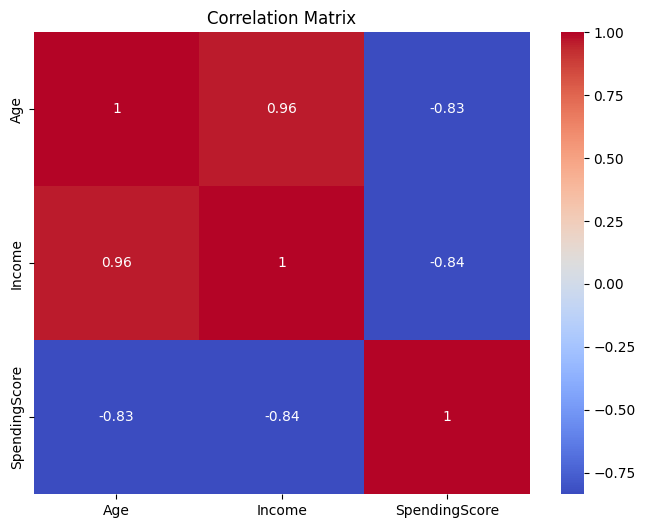

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
plt.savefig('correlation_matrix.png')

In [22]:
#pca
scaled = StandardScaler().fit_transform(df[['Age','Income','SpendingScore']])
pca = PCA(n_components=2)
pca_results=pca.fit(scaled)
pca_df = pd.DataFrame(pca.fit_transform(scaled),columns=['PC1','PC2'])
pca_df.to_csv('pca_results.csv')
pca_df

,PC1,PC2
0,-1.028297,-1.174777
1,-0.157458,0.143337
2,-1.102151,0.237293
3,1.580571,-0.162971
4,2.979178,0.056872
5,-2.433430,0.085015
6,0.228515,0.547881
7,-1.201658,-0.113422
8,2.271790,-0.134184
9,-1.137060,0.514957


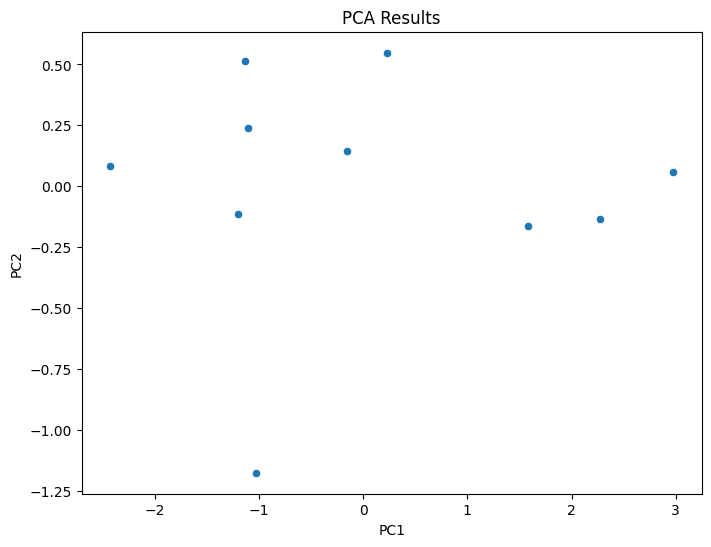

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1',y='PC2',data=pca_df)
plt.title('PCA Results')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig("pca_scatter_plot.png")
plt.show()

In [26]:
#MANOVA
manova = MANOVA.from_formula('Age + Income + SpendingScore ~ Region', data=df)
print(manova.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value   Num DF Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda   0.0045 3.0000 5.0000 367.3744 0.0000
         Pillai's trace   0.9955 3.0000 5.0000 367.3744 0.0000
 Hotelling-Lawley trace 220.4247 3.0000 5.0000 367.3744 0.0000
    Roy's greatest root 220.4247 3.0000 5.0000 367.3744 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
           Region         Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.1362 6.0000 10.0000  2.8497 0.0693
           Pillai's trace 0.9569 6.0000 12.0000  1.8349 0.1746
   Hotellin

In [28]:
kmeans = KMeans(n_clusters=2,random_state=0)
kmeans.fit(df[['Age','Income','SpendingScore']])
df['Cluster'] = kmeans.labels_

In [29]:
print("\nCluster Assignments:\n", df[['Age', 'Income', 'SpendingScore', 'Cluster']])



Cluster Assignments:
    Age  Income  SpendingScore  Cluster
0   25   50000             60        0
1   34   62000             65        0
2   28   58000             70        0
3   40   75000             55        1
4   52   80000             50        1
5   23   45000             75        0
6   37   67000             66        1
7   29   52000             68        0
8   45   78000             52        1
9   31   56000             72        0


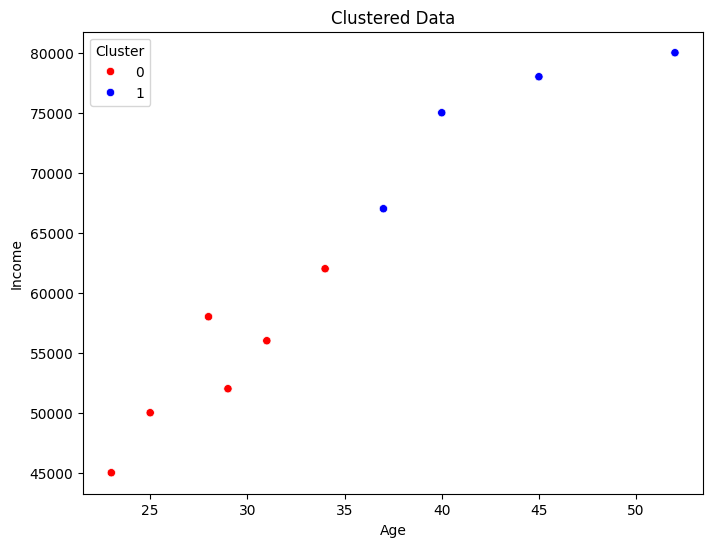

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age',y='Income',hue='Cluster',data=df,palette=['red','blue'])
plt.title('Clustered Data')
plt.xlabel('Age')
plt.ylabel('Income')
plt.savefig("clustered_data.png")
plt.show()

In [33]:
df.to_csv("multivariate_analysis_results.csv", index=False)

In [34]:
print("Final dataset with analysis results saved as 'multivariate_analysis_results.csv'")

Final dataset with analysis results saved as 'multivariate_analysis_results.csv'
